In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
import warnings
import timeit

C:\Users\thami\Documents\GitHub\TCC agrupamento\agrupamento-tcc\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden to 1 by setting random_state")

### Leitura de dados

In [3]:
df = pd.read_csv('../dados_processados/cursos-pos-processamento.csv',sep=';')

In [4]:
df_scaled = df.drop(['no_curso','co_curso'],axis=1)

### Funções

In [5]:
barnes_hut = 'barnes_hut'
exact = 'exact'
n_neighbors = 5
min_dist = 0.1
random_state = 42

In [6]:
def reduzir_dimensionalidade_PCA(n_components):
    #Reduzir dimensionalidade com PCA
    pca = PCA(n_components=n_components, random_state=random_state)
    data_pca = pca.fit_transform(df_scaled)

    return data_pca

In [7]:
def reduzir_dimensionalidade_t_sne(n_components, perplexity, method):
    #Reduzir dimensionalidade com t-SNE
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state, method=method)
    data_tsne = tsne.fit_transform(df_scaled)

    return data_tsne

In [8]:
def reduzir_dimensionalidade_UMAP(n_components, n_neighbors, min_dist):
    #Reduzir dimensionalidade com UMAP
    umap_model = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric='euclidean', random_state=random_state)
    data_umap = umap_model.fit_transform(df_scaled)

    return data_umap

### Análise tempo

#### Número de componentes = 2

In [9]:
pca_tempo_n_2 = timeit.timeit(lambda: reduzir_dimensionalidade_PCA(2), number=50)

In [10]:
tsne_tempo_n_2 = timeit.timeit(lambda: reduzir_dimensionalidade_t_sne(2, 40, barnes_hut), number=50)

In [11]:
umap_tempo_n_2 = timeit.timeit(lambda: reduzir_dimensionalidade_UMAP(2, n_neighbors, min_dist), number=50)

#### Número de componentes = 3

In [12]:
pca_tempo_n_3 = timeit.timeit(lambda: reduzir_dimensionalidade_PCA(3), number=50)

In [13]:
tsne_tempo_n_3 = timeit.timeit(lambda: reduzir_dimensionalidade_t_sne(3, 40, barnes_hut), number=50)

In [14]:
umap_tempo_n_3 = timeit.timeit(lambda: reduzir_dimensionalidade_UMAP(3, n_neighbors, min_dist), number=50)

### Gráficos

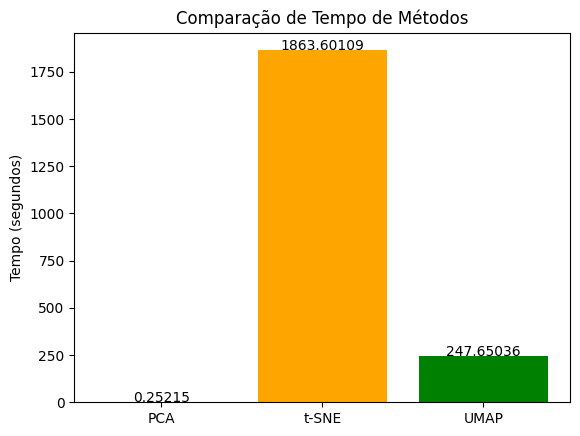

In [15]:
# Resultados simulados (substitua pelos valores reais)
metodos = ['PCA', 't-SNE', 'UMAP']
tempos = [pca_tempo_n_2, tsne_tempo_n_2, umap_tempo_n_2]

# Gráfico de barras
plt.bar(metodos, tempos, color=['blue', 'orange', 'green'])
plt.ylabel('Tempo (segundos)')
plt.title('Comparação de Tempo de Métodos')

for i, tempo in enumerate(tempos):
    plt.text(i, tempo + 0.01, f'{tempo:.5f}', ha='center', fontsize=10)

plt.show()

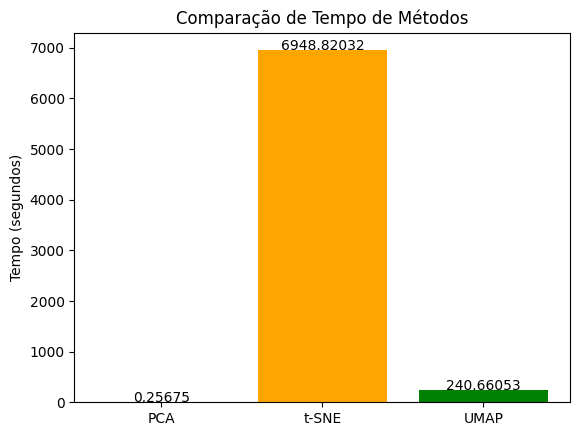

In [16]:
# Resultados simulados (substitua pelos valores reais)
metodos = ['PCA', 't-SNE', 'UMAP']
tempos = [pca_tempo_n_3, tsne_tempo_n_3, umap_tempo_n_3]

# Gráfico de barras
plt.bar(metodos, tempos, color=['blue', 'orange', 'green'])
plt.ylabel('Tempo (segundos)')
plt.title('Comparação de Tempo de Métodos')
for i, tempo in enumerate(tempos):
    plt.text(i, tempo + 0.01, f'{tempo:.5f}', ha='center', fontsize=10)
plt.show()